In [1]:
import os

os.environ["PYTENSOR_FLAGS"] = "cxx="

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import causalpy as cp

# 1. Load Data
ncaa_nba = pd.read_csv("data/ncaa_nba_data.csv")

# 2. Reshape to Long Format
# Assuming columns are player_id, num_years_college, college_4...college_1, nba_season_1...nba_season_5
# We melt the dataset so each row is a player-time period
value_vars = [
    "college_4",
    "college_3",
    "college_2",
    "college_1",
    "nba_season_1",
    "nba_season_2",
    "nba_season_3",
    "nba_season_4",
    "nba_season_5",
]

long_df = ncaa_nba.melt(
    id_vars=["athlete_id", "num_years_college"],
    value_vars=value_vars,
    var_name="period",
    value_name="impact",
).dropna(subset=["impact"])

# 3. Create standardized 'time' variable (1 to 9) and Treatment indicators
time_map = {k: i + 1 for i, k in enumerate(value_vars)}
long_df["time"] = long_df["period"].map(time_map)

# Group indicators for OLS
for g in [2, 3, 4]:
    long_df[f"g{g}"] = (long_df["num_years_college"] == g).astype(int)

# Create a binary treatment indicator for CausalPy (1 if the player is in the NBA, 0 if in college)
long_df["treated"] = (long_df["time"] >= 5).astype(int)

This code prepares a panel dataset of athletes’ performance before and after entering the NBA so it can be used in a difference‑in‑differences style analysis. It begins by importing the required Python libraries for data manipulation, statistical modeling, and visualization. The dataset `ncaa_nba_data.csv` is then loaded into a pandas DataFrame called `ncaa_nba`.

The original dataset is structured in wide format, where each player has separate columns for different seasons (e.g., `college_4`, `college_3`, …, `nba_season_5`). To analyze changes over time, the code reshapes the data into long format using `pandas.melt()`. In this new structure, each row represents a single player–time observation, with the column `period` indicating the season and `impact` containing the corresponding performance metric. Rows with missing impact values are removed to ensure the analysis only uses observed performance data.

Next, the code constructs a standardized time index. A dictionary maps each season label to a numeric time value from 1 to 9, allowing the timeline to be treated as an ordered sequence of periods relative to the NBA transition. The code also creates indicator variables (`g2`, `g3`, and `g4`) that identify players who spent two, three, or four years in college, respectively. These will later allow the regression to estimate differences in outcomes across groups with different college durations.

Finally, the code defines a treatment indicator that marks when a player enters the NBA. Periods corresponding to NBA seasons (time ≥ 5) are coded as treated, while college periods are coded as untreated. This binary variable allows the dataset to distinguish pre‑NBA and post‑NBA observations, enabling causal analysis of how outcomes change once players transition from college to the NBA.

#### OLS

In [11]:
formula = "impact ~ C(time) + g2:C(time) + g3:C(time) + g4:C(time) + C(athlete_id)"

ols_model = smf.ols(formula, data=long_df).fit(
    cov_type="cluster", cov_kwds={"groups": long_df["athlete_id"]}
)

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 impact   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                 1.169e+14
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:04:30   Log-Likelihood:                -11243.
No. Observations:                5080   AIC:                         2.416e+04
Df Residuals:                    4241   BIC:                         2.965e+04
Df Model:                         838                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/Users/brucechen/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 841, but rank is 32
  warnings.warn('covariance of constraints does not have full '


This code estimates a panel regression to analyze how player performance evolves over time and how those patterns differ by years spent in college. The model uses `impact` as the outcome variable and includes categorical time fixed effects (`C(time)`) to control for period‑specific changes that affect all players. It also includes player fixed effects (`C(athlete_id)`), which account for time‑invariant differences in ability across athletes.

The model interacts time with indicators for players who spent two, three, or four years in college (`g2`, `g3`, `g4`). These interaction terms allow the regression to estimate how performance trajectories differ for these groups relative to the baseline group of one‑year college players. This structure effectively produces an event‑study style set of coefficients describing how outcomes evolve across the nine periods surrounding the transition from college to the NBA.

The regression is estimated using ordinary least squares, with standard errors clustered at the athlete level. Clustering accounts for the fact that multiple observations belong to the same player over time, allowing for correlation in errors within individuals and producing more reliable statistical inference.

In [17]:
coefs = []

for name in ols_model.params.index:
    if name.startswith("g") and ":C(time)" in name:
        g = int(name[1])  # group number
        t = int(name.split("[")[1].split("]")[0])

        coefs.append(
            {
                "group": g,
                "time": t,
                "coef": ols_model.params[name],
                "ci_low": ols_model.conf_int().loc[name, 0],
                "ci_high": ols_model.conf_int().loc[name, 1],
            }
        )

coef_df = pd.DataFrame(coefs)
coef_df.columns

Index(['group', 'time', 'coef', 'ci_low', 'ci_high'], dtype='object')

This code extracts the key interaction coefficients from the regression results for use in visualization or further analysis. Specifically, it focuses on the interaction terms between time and the college‑experience indicators (`g2`, `g3`, and `g4`), which represent how performance trajectories differ for players with additional years in college relative to one‑year players.

The loop iterates over each group (two‑, three‑, and four‑year college players) and each time period in the dataset. For each combination, it constructs the corresponding coefficient name used in the regression output (e.g., `g2:C(time)[T.5]`). If that term exists in the estimated model, the code retrieves the coefficient value along with the lower and upper bounds of its confidence interval.

Each set of results is stored as a dictionary containing the group, time period, estimated effect, and confidence interval. These dictionaries are collected in a list and then converted into a pandas DataFrame (`coef_df`), which provides a clean structure for plotting the event‑study coefficients across time and comparing trajectories across groups.

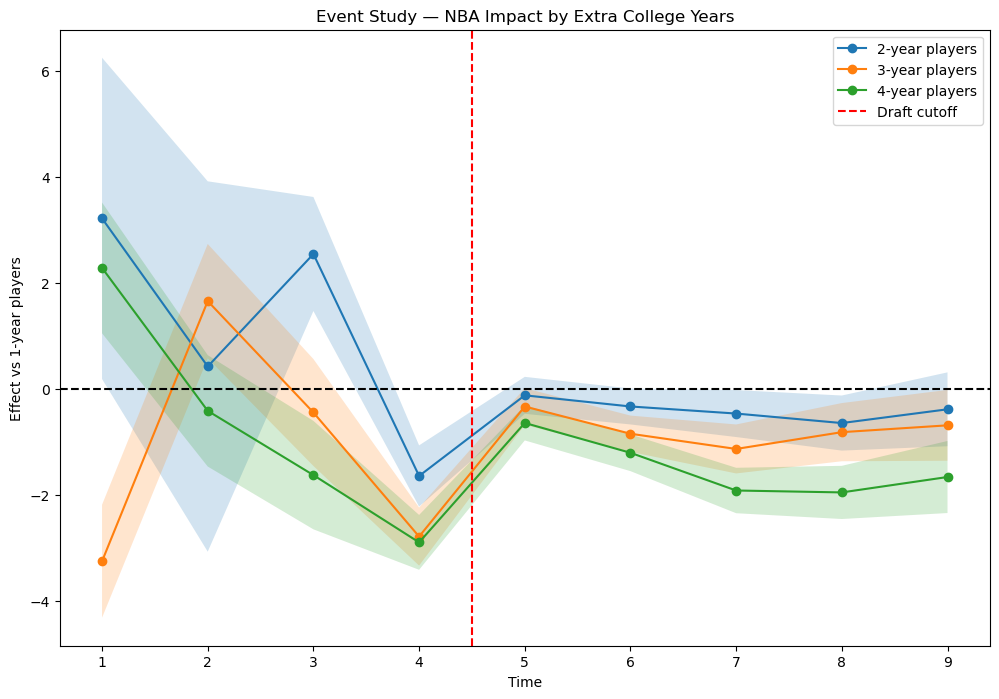

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))

for g in coef_df["group"].unique():
    gdf = coef_df[coef_df["group"] == g].sort_values("time")

    ax.plot(gdf["time"], gdf["coef"], marker="o", label=f"{g}-year players")
    ax.fill_between(gdf["time"], gdf["ci_low"], gdf["ci_high"], alpha=0.2)

ax.axhline(0, linestyle="--", color="black")
ax.axvline(4.5, linestyle="--", color="red", label="Draft cutoff")

ax.set_title("Event Study — NBA Impact by Extra College Years")
ax.set_xlabel("Time")
ax.set_ylabel("Effect vs 1‑year players")
ax.legend()

plt.show()